# 🧠 Entrenamiento + Evaluación MLP (TensorFlow/Keras) — 4 herramientas

**Versión básica**, sin tuneo (Optuna después). Misma arquitectura que el TFM de Jorge.

## Diferencias con el MLP de sklearn
- Aquí se usa **Keras**, que permite ver las **curvas de entrenamiento** (accuracy/loss por época).
- Las etiquetas se pasan a **one-hot** (formato que pide Keras para clasificación).
- Se puede usar **GPU** automáticamente si está disponible (en haruhi la hay).

## Arquitectura (igual que Jorge)
Dos capas ocultas (**16 y 8 neuronas**, ReLU) con regularización L2 y Dropout 0.3, capa de salida softmax. Optimizador Adam, pérdida categorical_crossentropy.

## Flujo (por herramienta)
1. Cargar 8 clases con `cargar_datos`.
2. Codificar `y` y pasar a one-hot.
3. Split 80/20 estratificado, seed 42.
4. **Normalizar** X con StandardScaler.
5. Entrenar la red (200 épocas, batch 200).
6. Predecir, medir tiempos, guardar historia de entrenamiento.

## Salidas
Tabla comparativa con **tiempos**, **matriz de confusión**, **curvas de entrenamiento** (accuracy y loss por época) y comparación con RF/XGB/LGBM/MLP-sklearn.

**Run All y listo.** Si no tienes TensorFlow: `pip install tensorflow`

In [1]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable


In [2]:
# ============================================================
# CELDA 0 — IMPORTS Y CONFIGURACIÓN
# ============================================================
import pandas as pd
import numpy as np
import time
import gc
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                              f1_score, confusion_matrix)

import warnings
warnings.filterwarnings('ignore')

# Reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

BASE_IN = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/BaseDatos')

CLASES = ['BenignTraffic', 'DictionaryBruteForce', 'Recon', 'Mirai',
          'Spoofing', 'DoS', 'DDoS', 'Web']
HERRAMIENTAS = ['CIC', 'Nemea', 'Tstat', 'Tshark']

SEED = 42
N_EPOCHS = 200
BATCH = 200

print('TensorFlow version:', tf.__version__)
print('GPUs disponibles:', tf.config.list_physical_devices('GPU'))
print(f'Clases: {len(CLASES)}  Herramientas: {HERRAMIENTAS}')

2026-07-27 02:08:46.728856: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-27 02:08:46.729754: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-27 02:08:46.736799: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-27 02:08:46.828433: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-27 02:08:48.887086: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warnin

TensorFlow version: 2.16.1
GPUs disponibles: []
Clases: 8  Herramientas: ['CIC', 'Nemea', 'Tstat', 'Tshark']


In [3]:
# ============================================================
# CELDA 1 — FUNCIÓN cargar_datos (idéntica a la del notebook RF)
# Devuelve (X, y) listos para entrenar, con las mismas reglas de
# filtrado: solo columnas comunes y eliminando sospechosas de fuga.
# ============================================================

def cargar_datos(herramienta, usar_solo_columnas_comunes=True, eliminar_sospechosas=True):
    dfs_por_clase = {}
    columnas_por_clase = {}

    for clase in CLASES:
        ruta = BASE_IN / clase / f'{herramienta}.csv'
        df_tmp = pd.read_csv(ruta, low_memory=False)
        dfs_por_clase[clase] = df_tmp
        columnas_por_clase[clase] = list(df_tmp.columns)

    print('\n' + '='*80)
    print(f'CARGA — {herramienta}')
    print('='*80)

    for clase in CLASES:
        df_tmp = dfs_por_clase[clase]
        print(f'{clase:<25} {df_tmp.shape[0]:,} filas x {df_tmp.shape[1]} columnas')

    conjuntos = [set(columnas_por_clase[clase]) for clase in CLASES]
    columnas_comunes_set = set.intersection(*conjuntos)
    columnas_union_set   = set.union(*conjuntos)

    if usar_solo_columnas_comunes:
        columnas_base = [c for c in columnas_por_clase[CLASES[0]] if c in columnas_comunes_set]
    else:
        columnas_base = sorted(columnas_union_set)

    patrones_fuga = [
        'label', 'etiqueta', 'class', 'attack', 'category', 'subtipo',
        'archivo', 'file', 'pcap',
        'flow_id', 'macaddr', 'mac', 'src_mac', 'dst_mac',
        'fqdn', 'sni', 'scn', 'dns_rslv', 'tls_sesid', 'npnalpn', 'alpn',
        'first_abs', 'req_tm', 'res_tm', 'handshaket', 'appdatat',
    ]

    columnas_id_exactas = {'id', 'ID', 'Flow ID', 'FLOW_ID', 'flow_id', 'uint64 FLOW_ID'}

    columnas_temporales_peligrosas_exactas = {
        'time* DBI_BRST_TIME_START', 'time* DBI_BRST_TIME_STOP',
        'time* SBI_BRST_TIME_START', 'time* SBI_BRST_TIME_STOP',
        'last', 'req_tm', 'res_tm', 's_first_abs',
        'c_first', 's_first', 'c_last', 's_last',
        'c_first_ack', 's_first_ack',
        'c_last_handshakeT', 's_last_handshakeT',
        'c_appdataT', 's_appdataT',
    }

    columnas_sospechosas = []
    if eliminar_sospechosas:
        for col in columnas_base:
            col_lower = col.lower()
            es_sospechosa_por_patron = any(p in col_lower for p in patrones_fuga)
            es_id = col in columnas_id_exactas or col_lower in columnas_id_exactas
            es_temporal_peligrosa = (
                col in columnas_temporales_peligrosas_exactas
                or col_lower in columnas_temporales_peligrosas_exactas
                or col_lower.startswith('time_ppi_pkt_times_')
            )
            if es_sospechosa_por_patron or es_id or es_temporal_peligrosa:
                columnas_sospechosas.append(col)

    if columnas_sospechosas:
        print(f'\n[{herramienta}] Columnas eliminadas por posible fuga directa: {len(columnas_sospechosas)}')

    columnas_finales = [c for c in columnas_base if c not in columnas_sospechosas]
    print(f'[{herramienta}] Columnas finales antes de concatenar: {len(columnas_finales)}')

    dfs = []
    for clase in CLASES:
        df_tmp = dfs_por_clase[clase][columnas_finales].copy()
        df_tmp['Label_Modelo'] = clase
        dfs.append(df_tmp)

    df = pd.concat(dfs, ignore_index=True, sort=False)
    y = df['Label_Modelo']
    X = df.drop(columns=['Label_Modelo'])

    cols_obj = X.select_dtypes(include=['object']).columns.tolist()
    if cols_obj:
        print(f'[{herramienta}] Columnas object codificadas con LabelEncoder: {len(cols_obj)}')
    for col in cols_obj:
        X[col] = X[col].fillna('__missing__').astype(str)
        X[col] = LabelEncoder().fit_transform(X[col])

    X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

    cols_constantes = [c for c in X.columns if X[c].nunique(dropna=False) <= 1]
    if cols_constantes:
        print(f'[{herramienta}] Columnas constantes eliminadas tras concatenar: {len(cols_constantes)}')
        X = X.drop(columns=cols_constantes)

    print(f'[{herramienta}] Shape final X: {X.shape}')
    return X, y

In [4]:
# ============================================================
# CELDA 2 — FUNCIÓN: entrenar MLP Keras y evaluar
# ============================================================

def entrenar_y_evaluar_keras(X, y, herramienta):
    # 1) Codificar y -> enteros -> one-hot
    le_y = LabelEncoder()
    y_enc = le_y.fit_transform(y)
    nombres_clase = list(le_y.classes_)
    n_clases = len(nombres_clase)

    # 2) Split estratificado 80/20
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc, test_size=0.2, random_state=SEED, stratify=y_enc
    )

    # 3) Normalizar
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    # 4) one-hot de las etiquetas
    y_train_oh = to_categorical(y_train, num_classes=n_clases)
    y_test_oh  = to_categorical(y_test,  num_classes=n_clases)

    # 5) Arquitectura tipo Jorge: 16 -> 8 -> softmax
    model = Sequential([
        Dense(16, activation='relu', kernel_regularizer=l2(0.001),
              input_shape=(X_train.shape[1],)),
        Dropout(0.3),
        Dense(8, activation='relu', kernel_regularizer=l2(0.001)),
        Dense(n_clases, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # 6) Entrenar (15% de train como validación para ver curvas)
    t0 = time.time()
    hist = model.fit(X_train, y_train_oh,
                     epochs=N_EPOCHS, batch_size=BATCH,
                     validation_split=0.15, verbose=0)
    t_train = time.time() - t0

    # 7) Predecir
    t0 = time.time()
    y_pred_oh = model.predict(X_test, verbose=0)
    t_pred = time.time() - t0
    y_pred = np.argmax(y_pred_oh, axis=1)

    n_test = len(X_test)
    metricas = {
        'Herramienta':       herramienta,
        'N features':        X.shape[1],
        'Accuracy':          accuracy_score(y_test, y_pred),
        'F1 macro':          f1_score(y_test, y_pred, average='macro'),
        'Recall macro':      recall_score(y_test, y_pred, average='macro'),
        'Precision macro':   precision_score(y_test, y_pred, average='macro'),
        'Tiempo train (s)':  t_train,
        'Tiempo pred (s)':   t_pred,
        'Pred us/muestra':   (t_pred / n_test) * 1e6,
    }

    cm = confusion_matrix(y_test, y_pred, labels=list(range(n_clases)))

    print(f'\n[{herramienta}] Accuracy: {metricas["Accuracy"]:.4f}  F1 macro: {metricas["F1 macro"]:.4f}')
    print(f'[{herramienta}] Tiempo train: {t_train:.2f}s | pred: {t_pred:.2f}s ({metricas["Pred us/muestra"]:.1f} us/muestra)')

    return metricas, cm, nombres_clase, hist

In [5]:
# ============================================================
# CELDA 3 — BUCLE PRINCIPAL: las 4 herramientas
# ============================================================

resultados = []
matrices_dict = {}
nombres_dict = {}
historias_dict = {}

for herr in HERRAMIENTAS:
    print('\n' + '#'*80)
    print(f'#  PROCESANDO {herr}')
    print('#'*80)

    X, y = cargar_datos(herr, usar_solo_columnas_comunes=True, eliminar_sospechosas=True)
    metricas, cm, nombres, hist = entrenar_y_evaluar_keras(X, y, herr)

    resultados.append(metricas)
    matrices_dict[herr] = cm
    nombres_dict[herr] = nombres
    historias_dict[herr] = hist

    del X, y
    gc.collect()


################################################################################
#  PROCESANDO CIC
################################################################################

CARGA — CIC
BenignTraffic             3,481 filas x 71 columnas
DictionaryBruteForce      3,481 filas x 71 columnas
Recon                     3,481 filas x 71 columnas
Mirai                     3,481 filas x 71 columnas
Spoofing                  3,481 filas x 71 columnas
DoS                       3,481 filas x 71 columnas
DDoS                      3,481 filas x 71 columnas
Web                       3,481 filas x 71 columnas

[CIC] Columnas eliminadas por posible fuga directa: 1
[CIC] Columnas finales antes de concatenar: 70
[CIC] Columnas constantes eliminadas tras concatenar: 1
[CIC] Shape final X: (27848, 69)

[CIC] Accuracy: 0.5384  F1 macro: 0.5325
[CIC] Tiempo train: 76.36s | pred: 0.64s (114.2 us/muestra)

################################################################################
#  PROCESANDO N

In [11]:
# ============================================================
# CELDA 4 — TABLA COMPARATIVA FINAL
# ============================================================

df_res = pd.DataFrame(resultados)

print('='*110)
print('  TABLA COMPARATIVA — MLP Keras (16, 8) — 200 épocas')
print('='*110)

df_show = df_res.copy()
for col in ['Accuracy', 'F1 macro', 'Recall macro', 'Precision macro']:
    df_show[col] = df_show[col].map(lambda v: f'{v:.4f}')
for col in ['Tiempo train (s)', 'Tiempo pred (s)']:
    df_show[col] = df_show[col].map(lambda v: f'{v:.3f}')
df_show['Pred us/muestra'] = df_show['Pred us/muestra'].map(lambda v: f'{v:.1f}')

print(df_show.to_string(index=False))

print('\n' + '='*110)
print('  REFERENCIA: F1 macro de los otros modelos')
print('='*110)
print('  Herramienta   N feats  RF       XGBoost  LightGBM')
print('  CIC                69   0.7099   0.7422   0.7427')
print('  Nemea             148   0.5829   0.5846   0.5853')
print('  Tstat              96   0.6311   0.6247   0.6273')
print('  Tshark             50   0.7434   0.7584   0.7531')

  TABLA COMPARATIVA — MLP Keras (16, 8) — 200 épocas
Herramienta  N features Accuracy F1 macro Recall macro Precision macro Tiempo train (s) Tiempo pred (s) Pred us/muestra
        CIC          69   0.5384   0.5325       0.5383          0.6076           76.356           0.636           114.2
      Nemea         148   0.5194   0.4965       0.5193          0.5737           62.510           0.865           155.4
      Tstat          96   0.4090   0.4006       0.4089          0.5697           77.089           0.363            65.2
     Tshark          50   0.4982   0.5056       0.4981          0.5696           72.578           0.770           138.2

  REFERENCIA: F1 macro de los otros modelos
  Herramienta   N feats  RF       XGBoost  LightGBM
  CIC                69   0.7099   0.7422   0.7427
  Nemea             148   0.5829   0.5846   0.5853
  Tstat              96   0.6311   0.6247   0.6273
  Tshark             50   0.7434   0.7584   0.7531


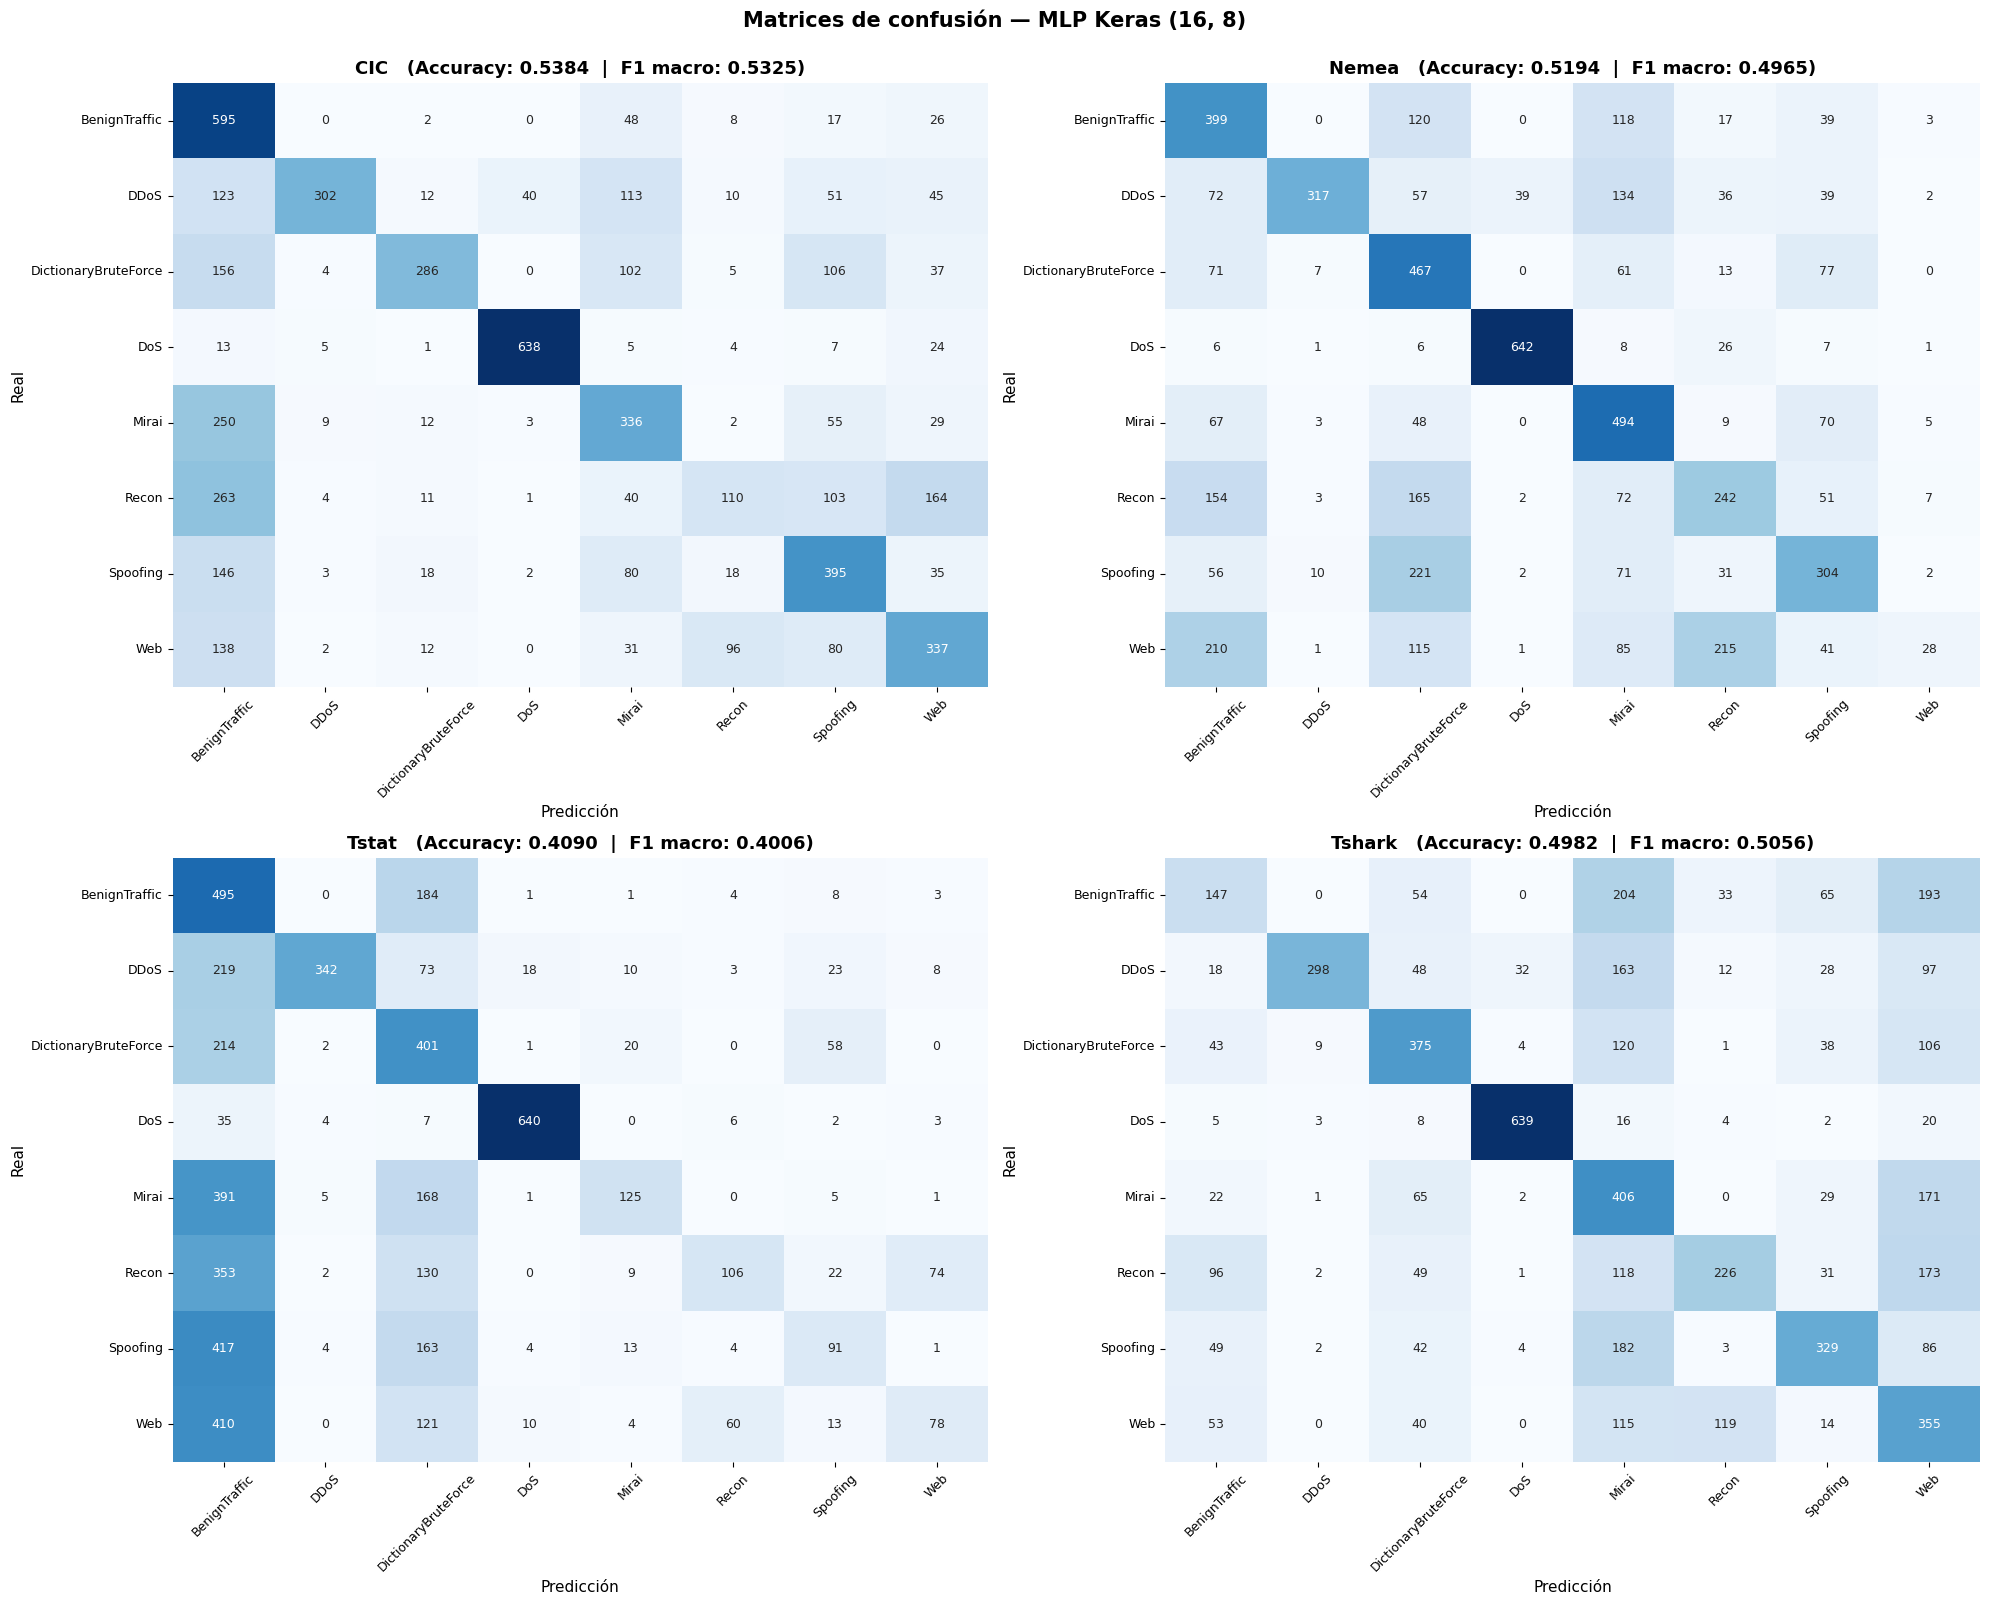

In [7]:
# ============================================================
# CELDA 5 — MATRICES DE CONFUSIÓN (grid 2×2)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.flatten()

for i, herr in enumerate(HERRAMIENTAS):
    cm = matrices_dict[herr]
    nombres = nombres_dict[herr]
    ax = axes[i]

    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=nombres, yticklabels=nombres,
        ax=ax, cbar=False, square=False,
        annot_kws={'size': 9}
    )

    acc = next(r['Accuracy'] for r in resultados if r['Herramienta'] == herr)
    f1  = next(r['F1 macro'] for r in resultados if r['Herramienta'] == herr)
    ax.set_title(f'{herr}   (Accuracy: {acc:.4f}  |  F1 macro: {f1:.4f})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicción', fontsize=11)
    ax.set_ylabel('Real', fontsize=11)
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.tick_params(axis='y', rotation=0,  labelsize=9)

plt.suptitle('Matrices de confusión — MLP Keras (16, 8)', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

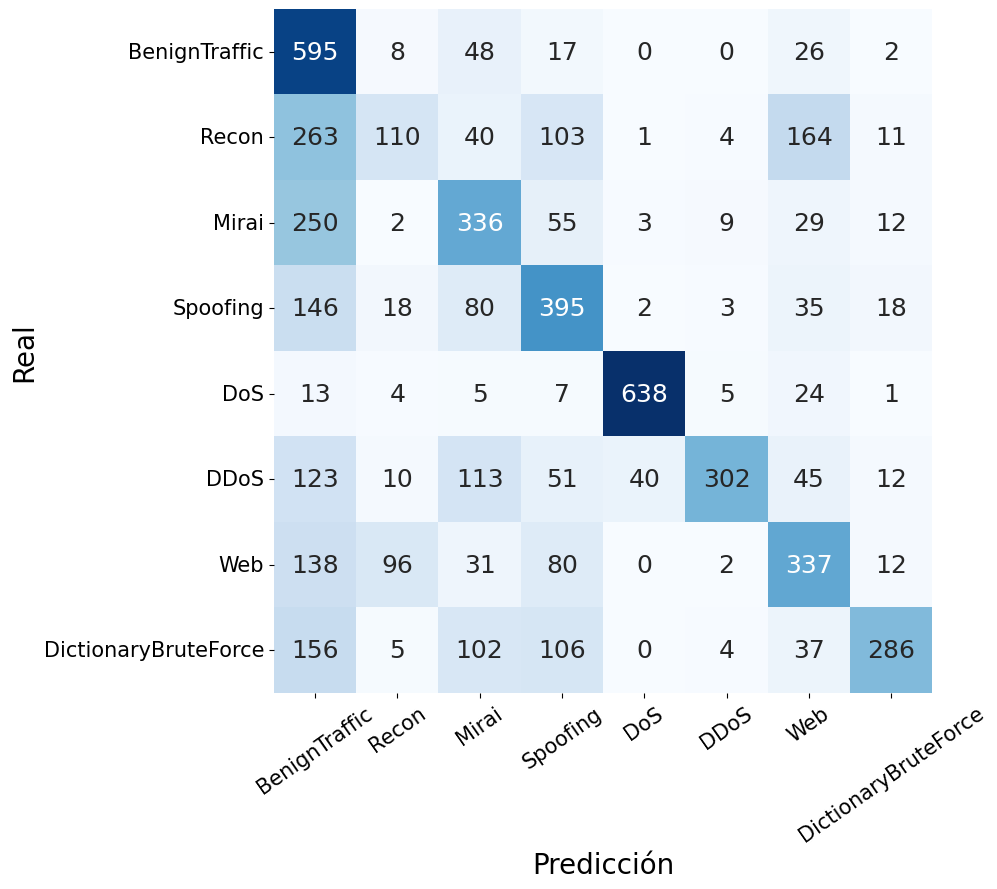

✓ Guardado: /home/miguel/Escritorio/TFM/TFM_Miguel/Figuras/cm_mlpkeras_basico_CIC.pdf


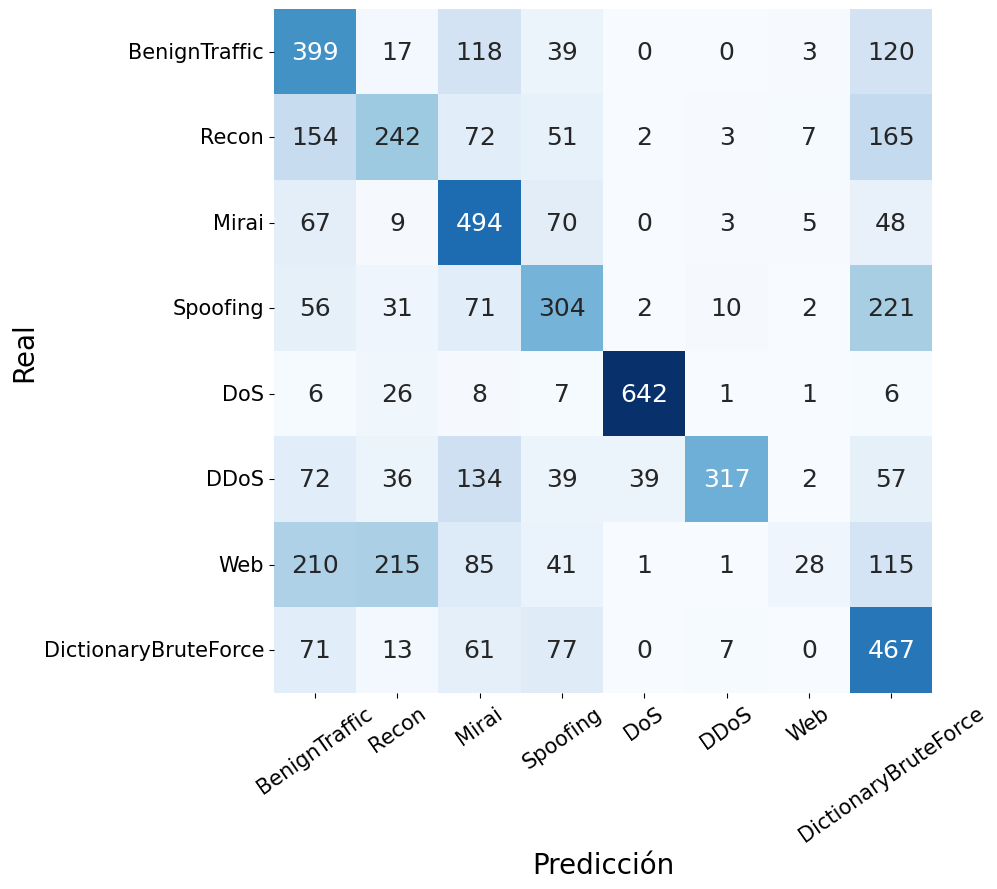

✓ Guardado: /home/miguel/Escritorio/TFM/TFM_Miguel/Figuras/cm_mlpkeras_basico_Nemea.pdf


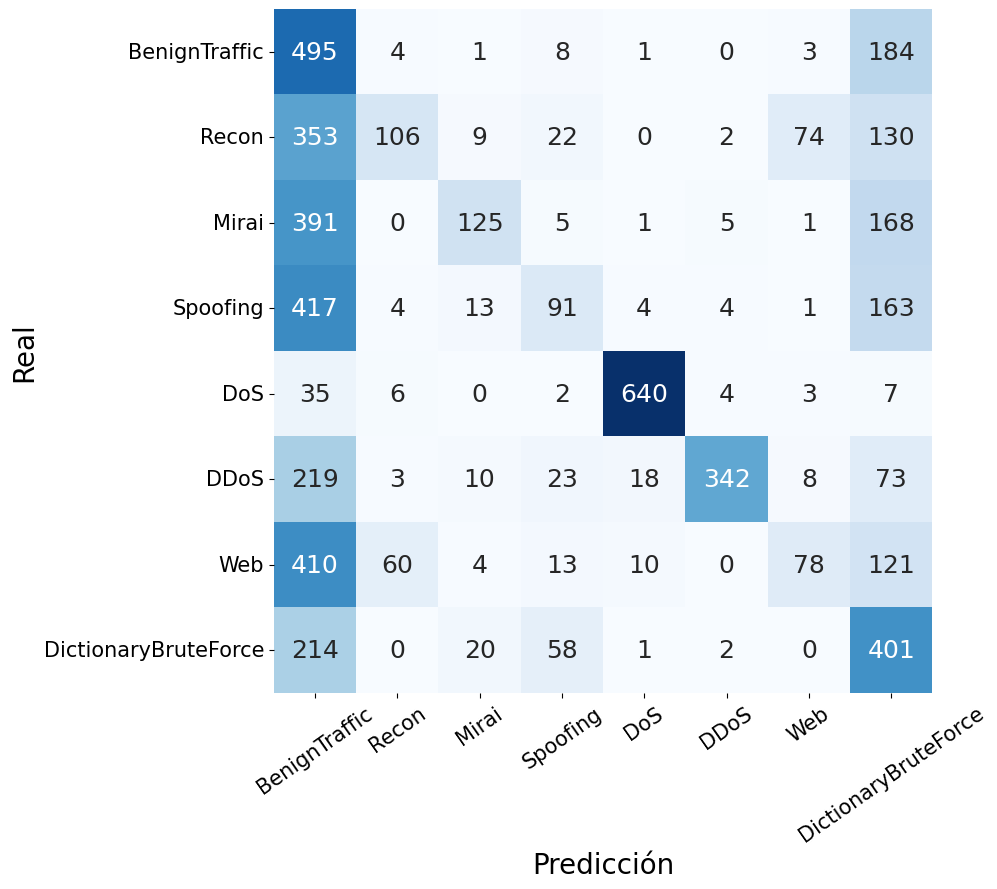

✓ Guardado: /home/miguel/Escritorio/TFM/TFM_Miguel/Figuras/cm_mlpkeras_basico_Tstat.pdf


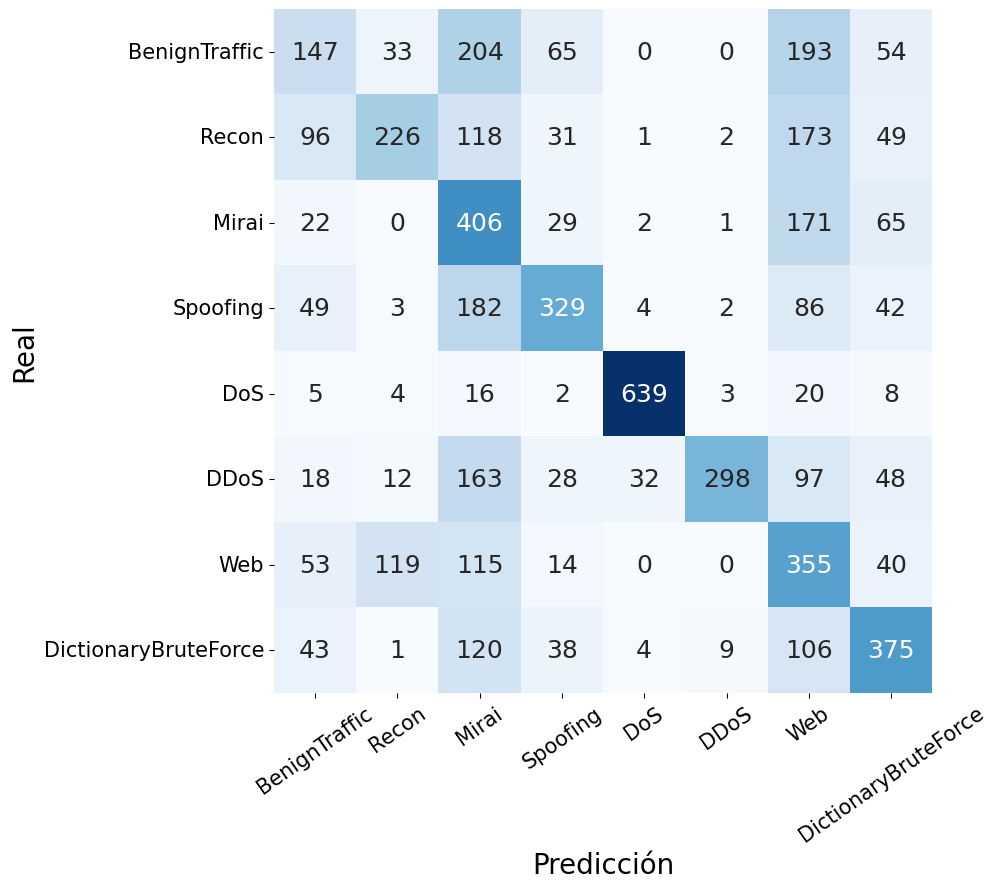

✓ Guardado: /home/miguel/Escritorio/TFM/TFM_Miguel/Figuras/cm_mlpkeras_basico_Tshark.pdf


In [8]:
# ============================================================
# CELDA 6 — Matrices de confusión (4 PDF separados, uno por herramienta)
# ============================================================

RUTA_FIGURAS = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/Figuras')
RUTA_FIGURAS.mkdir(parents=True, exist_ok=True)

ORDEN_FIGURA = ['BenignTraffic', 'Recon', 'Mirai', 'Spoofing',
                'DoS', 'DDoS', 'Web', 'DictionaryBruteForce']

for herr in HERRAMIENTAS:
    cm = matrices_dict[herr]
    nombres = nombres_dict[herr]
    perm = [nombres.index(c) for c in ORDEN_FIGURA]
    cm_ordenada = cm[perm][:, perm]

    fig, ax = plt.subplots(figsize=(10, 9))
    sns.heatmap(cm_ordenada, annot=True, fmt='d', cmap='Blues',
                xticklabels=ORDEN_FIGURA, yticklabels=ORDEN_FIGURA,
                cbar=False, ax=ax, annot_kws={'size': 18})

    ax.set_xlabel('Predicción', fontsize=20)
    ax.set_ylabel('Real', fontsize=20)
    ax.tick_params(axis='x', rotation=35, labelsize=15)
    ax.tick_params(axis='y', rotation=0,  labelsize=15)

    plt.tight_layout()
    ruta_pdf = RUTA_FIGURAS / f'cm_mlpkeras_basico_{herr}.pdf'
    fig.savefig(ruta_pdf, format='pdf', bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f'✓ Guardado: {ruta_pdf}')

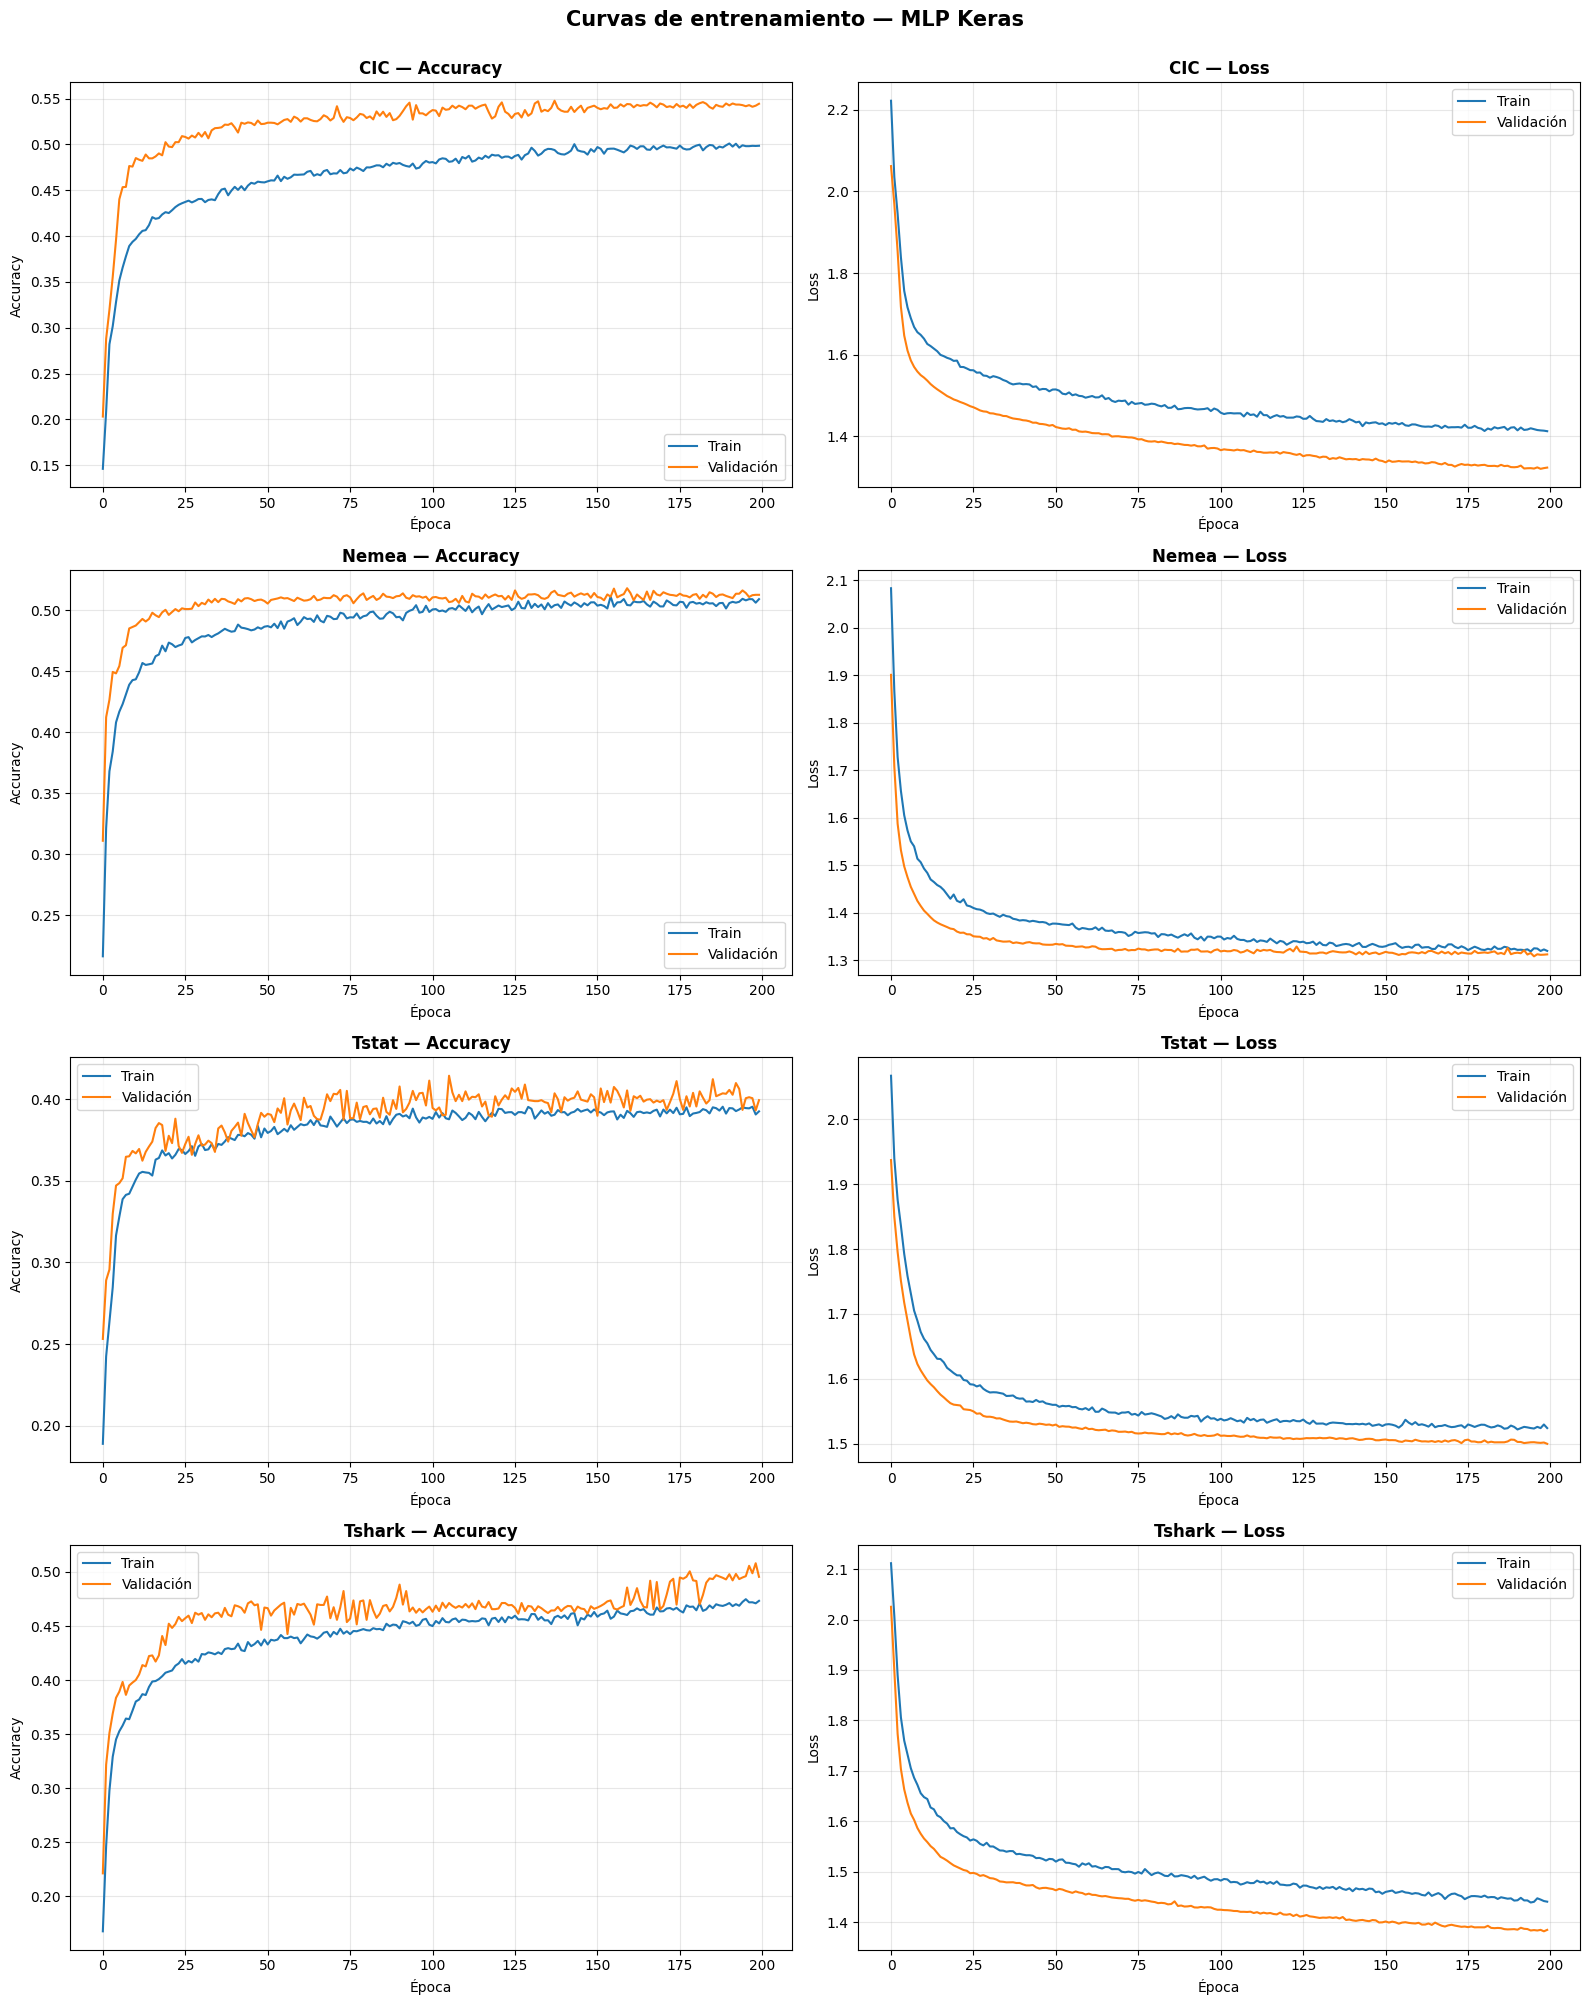

In [9]:
# ============================================================
# CELDA 7 — CURVAS DE ENTRENAMIENTO (accuracy y loss por época)
# Una fila por herramienta: izquierda accuracy, derecha loss
# ============================================================

fig, axes = plt.subplots(len(HERRAMIENTAS), 2, figsize=(16, 5*len(HERRAMIENTAS)))

for i, herr in enumerate(HERRAMIENTAS):
    hist = historias_dict[herr].history

    # Accuracy
    ax_acc = axes[i, 0]
    ax_acc.plot(hist['accuracy'], label='Train')
    ax_acc.plot(hist['val_accuracy'], label='Validación')
    ax_acc.set_title(f'{herr} — Accuracy', fontweight='bold')
    ax_acc.set_xlabel('Época'); ax_acc.set_ylabel('Accuracy')
    ax_acc.legend(); ax_acc.grid(alpha=0.3)

    # Loss
    ax_loss = axes[i, 1]
    ax_loss.plot(hist['loss'], label='Train')
    ax_loss.plot(hist['val_loss'], label='Validación')
    ax_loss.set_title(f'{herr} — Loss', fontweight='bold')
    ax_loss.set_xlabel('Época'); ax_loss.set_ylabel('Loss')
    ax_loss.legend(); ax_loss.grid(alpha=0.3)

plt.suptitle('Curvas de entrenamiento — MLP Keras', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

In [10]:
# CELDA THROUGHPUT — (cambia nombre modelo en el título)
import numpy as np

BYTES_MEDIO_FLUJO = {
    'CIC':    48,
    'Nemea':  101,
    'Tstat':  51,
    'Tshark': 206
} 

print('\n' + '='*70)
print('  THROUGHPUT — MLP-Keras')
print('='*70)
print(f'  {"Herramienta":10s}  {"µs/muestra":12s}  {"Flujos/s":12s}  {"Throughput (Mbps)":18s}')
print(f'  {"-"*10}  {"-"*12}  {"-"*12}  {"-"*18}')

for res in resultados:
    herr = res['Herramienta']
    us_muestra = res['Pred us/muestra']
    flujos_s = 1e6 / us_muestra
    bytes_medio = BYTES_MEDIO_FLUJO[herr]
    throughput_mbps = (flujos_s * bytes_medio * 8) / 1e6
    print(f'  {herr:10s}  {us_muestra:12.1f}  {flujos_s:12.0f}  {throughput_mbps:18.1f}')


  THROUGHPUT — MLP-Keras
  Herramienta  µs/muestra    Flujos/s      Throughput (Mbps) 
  ----------  ------------  ------------  ------------------
  CIC                114.2          8757                 3.4
  Nemea              155.4          6437                 5.2
  Tstat               65.2         15336                 6.3
  Tshark             138.2          7237                11.9
